# Solving the Burgers' equation using a physics informed neural network (PINN)

In [1]:
# Import necessary libraries

import torch
from torch import nn
from torch.autograd import grad

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set up device agnostic code

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Parameters

nu = 0.01            # Viscosity
x_l, x_u = -1.0, 1.0 # Lower and upper boundaries for x
t_l, t_u = 0.0, 1.0  # Lower and upper boundaries for t

In [4]:
def u_0(x):
  """Initial condition function"""
  return -torch.sin(np.pi * x)

In [5]:
class PINN(nn.Module):
  def __init__(self, input_shape, output_shape, hidden_units):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Tanh(),
        nn.Linear(in_features=hidden_units,
                  out_features=hidden_units),
        nn.Tanh(),
        nn.Linear(in_features=hidden_units,
                  out_features=hidden_units),
        nn.Tanh(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [6]:
def derivatives(u, xt):
  """Calculate necessary derivatives of u using torch.autograd.grad. Used for calculating PDE loss later"""
  grads = grad(u, xt, grad_outputs=torch.ones_like(u), create_graph=True)[0]
  u_x = grads[:, 0:1]
  u_t = grads[:, 1:2]

  u_xx = grad(u_x, xt, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
  return u_x, u_t, u_xx

In [7]:
N_f = 2000 # Number of collocation points
N_ic = 200 # Number of initial condition points
N_bc = 200 # Number of boundary condition points

In [8]:
# Collocation points
x_f = torch.rand(N_f, 1, device=device) * (x_u - x_l) + x_l
t_f = torch.rand(N_f, 1, device=device) * (t_u - t_l) + t_l

xt_f = torch.cat([x_f, t_f], dim=1)
xt_f.requires_grad_(True);

In [9]:
# Initial conditions

x_ic = torch.linspace(x_l, x_u, N_ic, device=device).reshape(-1, 1)
t_ic = torch.zeros_like(x_ic)
xt_ic = torch.cat([x_ic, t_ic], dim=1)
u_ic_vals = u_0(x_ic)

xt_ic = xt_ic.to(device)
u_ic_vals = u_ic_vals.to(device)

In [10]:
# Boundary conditions

t_bc = torch.rand(N_bc, 1, device=device) * (t_u - t_l) + t_l
x_bc_left = (torch.ones(N_bc, 1, device=device) * x_l)
x_bc_right = (torch.ones(N_bc, 1, device=device) * x_u)
xt_bc_left = torch.cat([x_bc_left, t_bc], dim=1)
xt_bc_right = torch.cat([x_bc_right, t_bc], dim=1)
u_bc_vals = torch.zeros_like(t_bc)

xt_bc_left = xt_bc_left.to(device)
xt_bc_right = xt_bc_right.to(device)
u_bc_vals = u_bc_vals.to(device)

In [11]:
model = PINN(input_shape=2, output_shape=1, hidden_units=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
# Training

epochs = 10000

for epoch in range(1, epochs+1):
    model.train()
    optimizer.zero_grad()

    # PDE loss at collocation points
    u_f = model(xt_f)
    u_x_f, u_t_f, u_xx_f = derivatives(u_f, xt_f)
    residual = u_t_f + u_f * u_x_f - nu * u_xx_f
    loss_pde = torch.mean(residual**2)

    # Initial condition loss
    u_ic_pred = model(xt_ic)
    loss_ic = torch.mean((u_ic_pred - u_ic_vals)**2)

    # Boundary condition loss
    u_bc_left = model(xt_bc_left)
    u_bc_right = model(xt_bc_right)
    loss_bc = torch.mean((u_bc_left - u_bc_vals)**2) + torch.mean((u_bc_right - u_bc_vals)**2)

    loss = loss_pde + loss_ic + loss_bc
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:6d} | Loss {loss.item():.3e} | PDE {loss_pde.item():.3e} | IC {loss_ic.item():.3e} | BC {loss_bc.item():.3e}")

Epoch   1000 | Loss 8.765e-03 | PDE 5.237e-03 | IC 3.161e-03 | BC 3.671e-04
Epoch   2000 | Loss 4.189e-03 | PDE 2.775e-03 | IC 1.012e-03 | BC 4.021e-04
Epoch   3000 | Loss 1.501e-03 | PDE 1.106e-03 | IC 3.384e-04 | BC 5.655e-05
Epoch   4000 | Loss 6.227e-04 | PDE 4.882e-04 | IC 1.251e-04 | BC 9.400e-06
Epoch   5000 | Loss 4.876e-04 | PDE 4.174e-04 | IC 5.872e-05 | BC 1.149e-05
Epoch   6000 | Loss 8.790e-04 | PDE 6.437e-04 | IC 1.114e-04 | BC 1.240e-04
Epoch   7000 | Loss 2.956e-03 | PDE 2.711e-03 | IC 9.166e-05 | BC 1.528e-04
Epoch   8000 | Loss 2.260e-04 | PDE 2.035e-04 | IC 1.581e-05 | BC 6.704e-06
Epoch   9000 | Loss 2.956e-04 | PDE 2.221e-04 | IC 3.142e-05 | BC 4.199e-05
Epoch  10000 | Loss 1.622e-04 | PDE 1.014e-04 | IC 1.900e-05 | BC 4.186e-05


In [13]:
solution = np.load("burgers_solution.npy")

In [14]:
model.eval()

(nx, nt) = (solution.T).shape # Number of spatial and temporal points we evaluate on

x = torch.linspace(x_l, x_u, nx, device=device)
t = torch.linspace(t_l, t_u, nt, device=device)
X, T = torch.meshgrid(x, t, indexing='xy')
xt = torch.stack([X, T], dim=-1).reshape(-1, 2)

with torch.no_grad():
    u_pred = model(xt).view(nt, nx).cpu().numpy()

diff = solution - u_pred

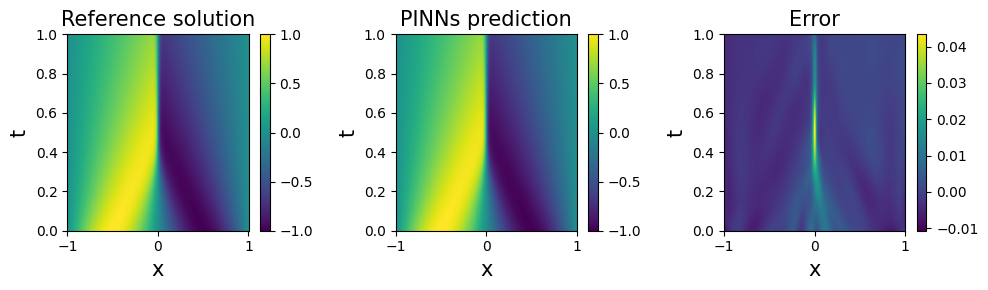

In [15]:
fig = plt.figure(figsize=[10,3])
axes = fig.subplots(1,3, sharex=False, sharey=False)

axes[0].set_title('Reference solution', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
image_0 = axes[0].pcolormesh(np.linspace(x_l, x_u, nx), np.linspace(t_l, t_u, nt), solution, shading='auto')
fig.colorbar(image_0, ax=axes[0])

axes[1].set_title('PINNs prediction', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
image_1 = axes[1].pcolormesh(np.linspace(x_l, x_u, nx), np.linspace(t_l, t_u, nt), u_pred, shading='auto')
fig.colorbar(image_1, ax=axes[1])

axes[2].set_title('Error', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
image_2 = axes[2].pcolormesh(np.linspace(x_l, x_u, nx), np.linspace(t_l, t_u, nt), diff, shading='auto')
fig.colorbar(image_2, ax=axes[2])

plt.tight_layout()
plt.show()